# 03. Baseline Model — Logistic Regression

**Objective:** Establish a strong baseline using Logistic Regression on the preprocessed data from `02_processed/`.
This model serves as the reference point for all subsequent models (Random Forest, MLP, Elastic Net).

**Key metric:** ROC-AUC — $AUC = P(\text{score}(\text{pos}) > \text{score}(\text{neg}))$

**Two training sets compared:**
- `X_train` / `y_train` — original imbalanced training set (~8% default rate)
- `X_train_smote` / `y_train_smote` — SMOTE-resampled (50/50 balance)

**Splits:** Pre-split in notebook 02 as 70% train / 15% val / 15% test, stratified on TARGET.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)

SEED = 42
np.random.seed(SEED)

print("Libraries imported successfully.")
print(f"numpy {np.__version__}  |  pandas {pd.__version__}")

Libraries imported successfully.
numpy 2.0.2  |  pandas 2.2.2


## 1. Load Processed Data

Mount Google Drive and load all six splits produced by notebook 02.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/02_processed"

# --- Load all splits ---
X_train       = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_train_smote = pd.read_csv(f"{DATA_DIR}/X_train_smote.csv")
X_val         = pd.read_csv(f"{DATA_DIR}/X_val.csv")
X_test        = pd.read_csv(f"{DATA_DIR}/X_test.csv")

y_train       = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze()
y_train_smote = pd.read_csv(f"{DATA_DIR}/y_train_smote.csv").squeeze()
y_val         = pd.read_csv(f"{DATA_DIR}/y_val.csv").squeeze()
y_test        = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze()

feature_names = pd.read_csv(f"{DATA_DIR}/feature_names.csv", header=None).squeeze().tolist()

print("=== Shapes ===")
print(f"X_train       : {X_train.shape}")
print(f"X_train_smote : {X_train_smote.shape}")
print(f"X_val         : {X_val.shape}")
print(f"X_test        : {X_test.shape}")
print(f"\n=== Target distribution ===")
print(f"Train (original) default rate : {y_train.mean():.4f}")
print(f"Train (SMOTE)    default rate : {y_train_smote.mean():.4f}")
print(f"Val              default rate : {y_val.mean():.4f}")
print(f"Test             default rate : {y_test.mean():.4f}")
print(f"\nNumber of features: {len(feature_names)}")

Mounted at /content/drive
=== Shapes ===
X_train       : (215253, 113)
X_train_smote : (395752, 113)
X_val         : (46126, 113)
X_test        : (46126, 113)

=== Target distribution ===
Train (original) default rate : 0.0807
Train (SMOTE)    default rate : 0.5000
Val              default rate : 0.0807
Test             default rate : 0.0807

Number of features: 113


## 2. Quick Sanity Checks

Verify feature names align with the loaded arrays and check for any residual NaNs.

In [3]:
# Assign column names from feature_names.csv (consistent across all splits)
for df in [X_train, X_train_smote, X_val, X_test]:
    df.columns = feature_names

# Check for NaNs — should all be 0 since the preprocessing pipeline already imputed everything
nan_counts = {
    "X_train"      : X_train.isna().sum().sum(),
    "X_train_smote": X_train_smote.isna().sum().sum(),
    "X_val"        : X_val.isna().sum().sum(),
    "X_test"       : X_test.isna().sum().sum(),
}
print("NaN counts per split:")
for k, v in nan_counts.items():
    status = "✓ clean" if v == 0 else f"⚠ {v} NaNs"
    print(f"  {k:20s}: {status}")

print("\nSample of X_train:")
X_train.head(3)

NaN counts per split:
  X_train             : ✓ clean
  X_train_smote       : ✓ clean
  X_val               : ✓ clean
  X_test              : ✓ clean

Sample of X_train:


,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,NAME_EDUCATION_TYPE,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_M,...,AMT_REQ_CREDIT_BUREAU_YEAR,age_years,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_TERM,CREDIT_GOODS_RATIO,EXT_SOURCE_1_MISSING,EXT_SOURCE_2_MISSING,EXT_SOURCE_3_MISSING,DAYS_EMPLOYED_ANOM
0,0.126557,-0.351502,0.406307,-0.526846,0.011473,-0.853766,-0.433329,1.0,0.0,0.0,...,-1.007674,-1.392132,-0.601720,0.055504,-1.152794,1.140045,1.0,0.0,0.0,0.0
1,-1.638460,-0.540370,-0.986108,-0.593132,1.089658,0.605193,1.157464,1.0,0.0,0.0,...,-1.007674,1.384629,0.308208,0.251766,0.224196,0.287075,0.0,0.0,0.0,1.0
2,-1.638460,-1.123790,-0.605315,-1.355713,0.011473,0.739727,-0.954118,1.0,0.0,0.0,...,0.690145,-0.780043,-0.298650,0.747874,-1.157940,1.566587,1.0,0.0,0.0,0.0


## 3. Helper Functions

Centralise evaluation so both models (original vs SMOTE) are compared identically.

In [4]:
def evaluate_model(model, X, y, split_name="Val", threshold=0.5):
    """
    Compute and print key classification metrics for a given split.
    Returns a dict with scalar metrics for easy comparison.
    """
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    roc_auc = roc_auc_score(y, y_prob)
    pr_auc  = average_precision_score(y, y_prob)

    print(f"\n{'='*55}")
    print(f"  {split_name} — threshold = {threshold}")
    print(f"{'='*55}")
    print(f"  ROC-AUC : {roc_auc:.4f}")
    print(f"  PR-AUC  : {pr_auc:.4f}")
    print(f"\n{classification_report(y, y_pred, target_names=['No Default (0)', 'Default (1)'])}")

    return {"split": split_name, "roc_auc": roc_auc, "pr_auc": pr_auc}


def plot_evaluation(model, X_val, y_val, X_test, y_test, title_prefix=""):
    """
    Side-by-side: confusion matrix (val), ROC curve (val + test),
    and Precision-Recall curve (val + test).
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{title_prefix} — Evaluation Plots", fontsize=14, fontweight='bold')

    # --- Confusion matrix (val set at 0.5 threshold) ---
    y_prob_val  = model.predict_proba(X_val)[:, 1]
    y_pred_val  = (y_prob_val >= 0.5).astype(int)
    cm = confusion_matrix(y_val, y_pred_val)
    ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot(
        ax=axes[0], colorbar=False, cmap="Blues"
    )
    axes[0].set_title("Confusion Matrix (Val, threshold=0.5)")

    # --- ROC curve ---
    for X, y, label in [(X_val, y_val, "Val"), (X_test, y_test, "Test")]:
        y_prob = model.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(y, y_prob)
        auc = roc_auc_score(y, y_prob)
        axes[1].plot(fpr, tpr, label=f"{label} (AUC={auc:.4f})")
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()

    # --- Precision-Recall curve ---
    for X, y, label in [(X_val, y_val, "Val"), (X_test, y_test, "Test")]:
        y_prob = model.predict_proba(X)[:, 1]
        prec, rec, _ = precision_recall_curve(y, y_prob)
        ap = average_precision_score(y, y_prob)
        axes[2].plot(rec, prec, label=f"{label} (AP={ap:.4f})")
    baseline_rate = y_val.mean()
    axes[2].axhline(baseline_rate, color='k', linestyle='--', linewidth=0.8,
                    label=f"Random baseline ({baseline_rate:.3f})")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].set_title("Precision-Recall Curve")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

print("Helper functions defined.")

Helper functions defined.


## 4. Train Baseline Model — Original Training Set

Logistic Regression with `class_weight='balanced'` to compensate for the ~8% default rate.
`lbfgs` solver with L2 regularisation (default C=1.0). `max_iter=1000` to ensure convergence.

> **Note:** We use `class_weight='balanced'` rather than SMOTE here. Section 5 trains on
> the SMOTE set so we can directly compare both strategies on the same val/test splits.

In [5]:
lr_base = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=SEED,
    n_jobs=-1,
)

print("Training Logistic Regression on original (imbalanced) training set...")
lr_base.fit(X_train, y_train)
print(f"  Converged in {lr_base.n_iter_[0]} iterations.")

Training Logistic Regression on original (imbalanced) training set...
  Converged in 91 iterations.


### 4.1 Evaluate on Validation Set


  Val  (original train) — threshold = 0.5
  ROC-AUC : 0.7494
  PR-AUC  : 0.2253

                precision    recall  f1-score   support

No Default (0)       0.96      0.69      0.80     42402
   Default (1)       0.16      0.68      0.26      3724

      accuracy                           0.69     46126
     macro avg       0.56      0.68      0.53     46126
  weighted avg       0.90      0.69      0.76     46126


  Test (original train) — threshold = 0.5
  ROC-AUC : 0.7521
  PR-AUC  : 0.2350

                precision    recall  f1-score   support

No Default (0)       0.96      0.69      0.80     42402
   Default (1)       0.16      0.68      0.26      3724

      accuracy                           0.69     46126
     macro avg       0.56      0.69      0.53     46126
  weighted avg       0.90      0.69      0.76     46126



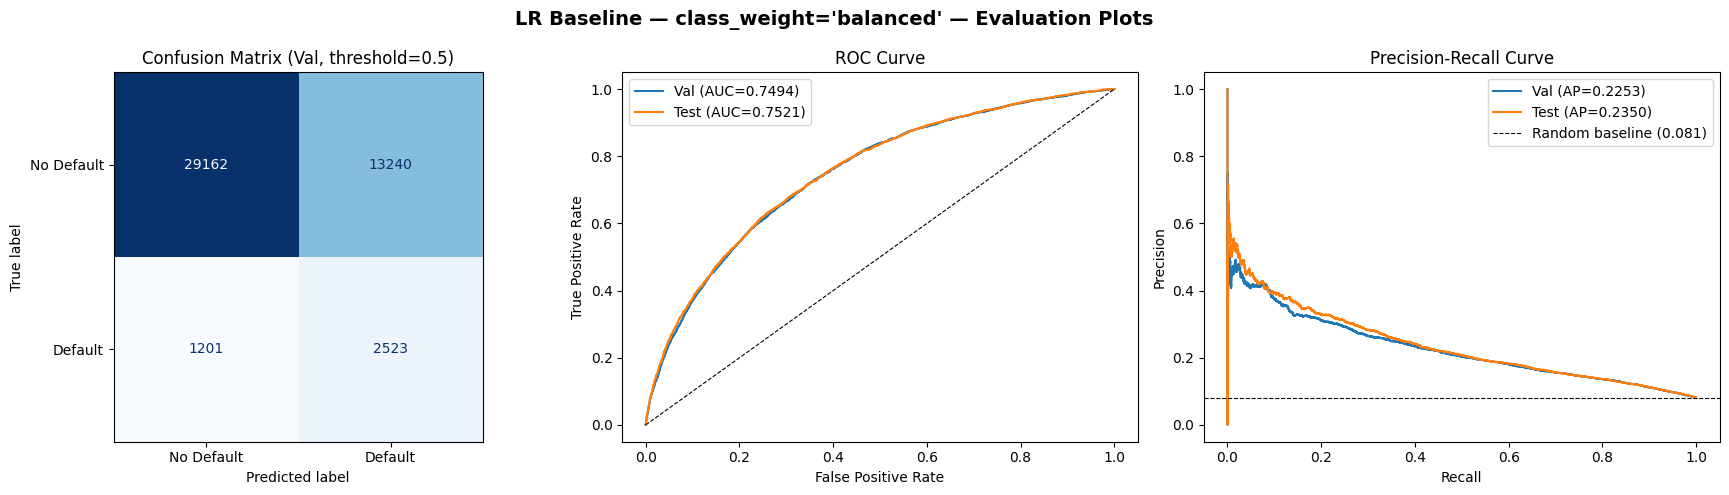

In [6]:
results_base_val  = evaluate_model(lr_base, X_val,  y_val,  split_name="Val  (original train)")
results_base_test = evaluate_model(lr_base, X_test, y_test, split_name="Test (original train)")

plot_evaluation(lr_base, X_val, y_val, X_test, y_test,
                title_prefix="LR Baseline — class_weight='balanced'")

## 5. Train Baseline Model — SMOTE Training Set

Same hyperparameters, trained on the SMOTE-balanced set. SMOTE creates synthetic minority
samples during training — val/test remain the original distribution so evaluation is fair.

Training Logistic Regression on SMOTE-resampled training set...
  Converged in 131 iterations.

  Val  (SMOTE train) — threshold = 0.5
  ROC-AUC : 0.7418
  PR-AUC  : 0.2234

                precision    recall  f1-score   support

No Default (0)       0.96      0.69      0.80     42402
   Default (1)       0.16      0.66      0.25      3724

      accuracy                           0.69     46126
     macro avg       0.56      0.67      0.53     46126
  weighted avg       0.89      0.69      0.76     46126


  Test (SMOTE train) — threshold = 0.5
  ROC-AUC : 0.7451
  PR-AUC  : 0.2286

                precision    recall  f1-score   support

No Default (0)       0.96      0.70      0.81     42402
   Default (1)       0.16      0.66      0.26      3724

      accuracy                           0.69     46126
     macro avg       0.56      0.68      0.53     46126
  weighted avg       0.89      0.69      0.76     46126



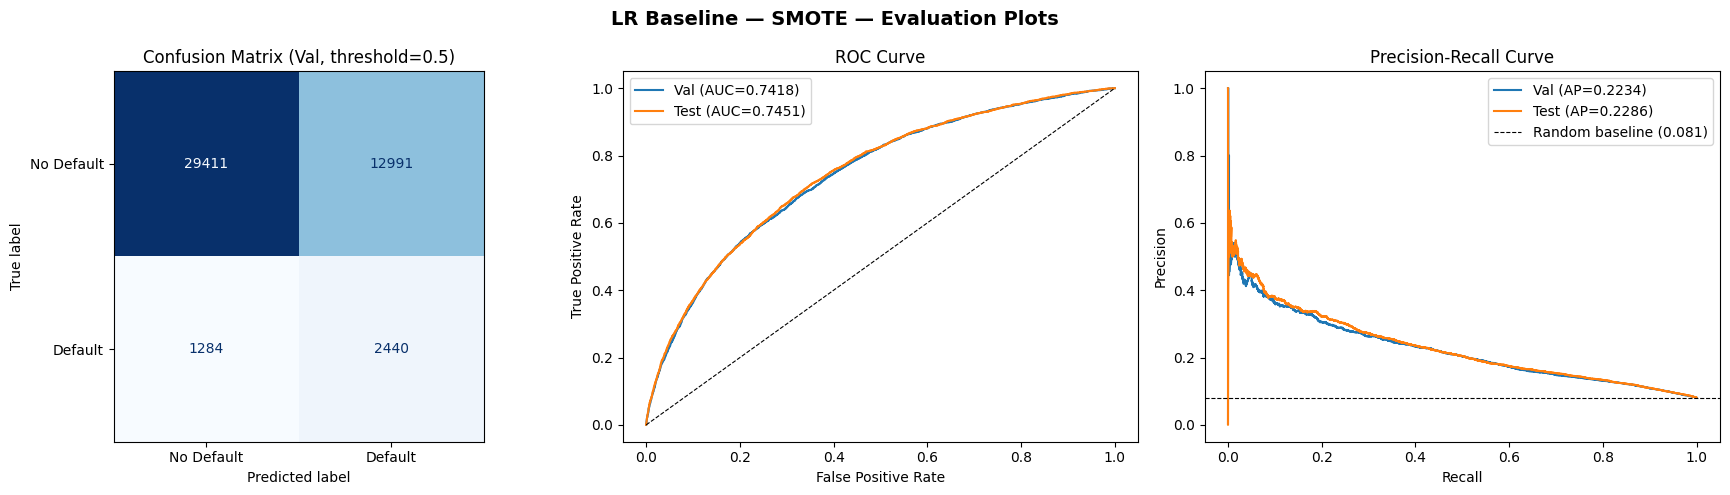

In [7]:
lr_smote = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight=None,     # class imbalance handled by SMOTE, not by weighting
    solver='lbfgs',
    max_iter=1000,
    random_state=SEED,
    n_jobs=-1,
)

print("Training Logistic Regression on SMOTE-resampled training set...")
lr_smote.fit(X_train_smote, y_train_smote)
print(f"  Converged in {lr_smote.n_iter_[0]} iterations.")

results_smote_val  = evaluate_model(lr_smote, X_val,  y_val,  split_name="Val  (SMOTE train)")
results_smote_test = evaluate_model(lr_smote, X_test, y_test, split_name="Test (SMOTE train)")

plot_evaluation(lr_smote, X_val, y_val, X_test, y_test,
                title_prefix="LR Baseline — SMOTE")

## 6. Model Comparison Summary

Side-by-side ROC-AUC and PR-AUC for both training strategies across val and test splits.

=== Baseline Logistic Regression — Results Summary ===

Training Set                 Split  ROC-AUC   PR-AUC
    Original Val  (original train) 0.749435 0.225336
    Original Test (original train) 0.752085 0.234959
       SMOTE    Val  (SMOTE train) 0.741794 0.223440
       SMOTE    Test (SMOTE train) 0.745138 0.228635


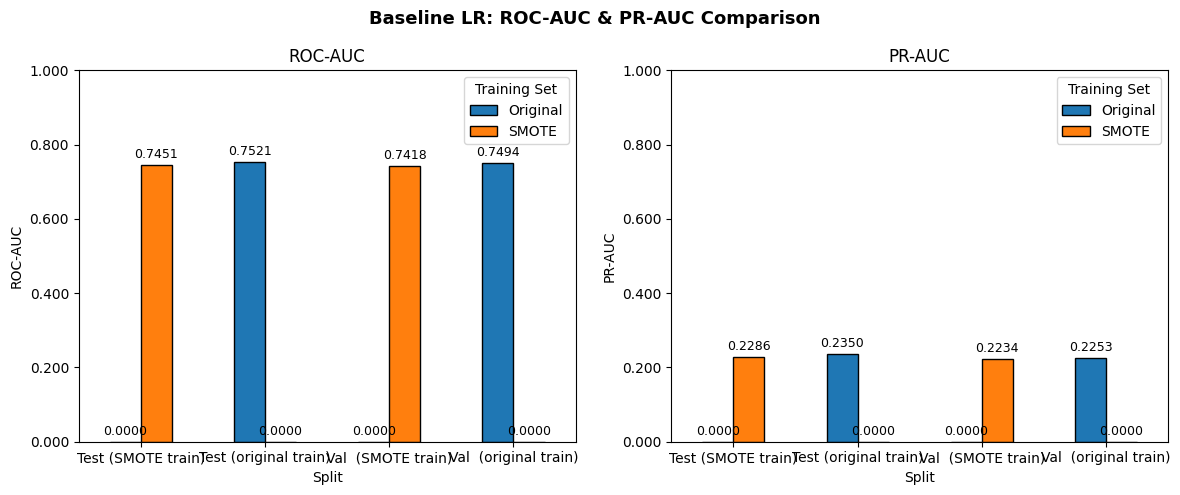

In [8]:
summary = pd.DataFrame([
    results_base_val,
    results_base_test,
    results_smote_val,
    results_smote_test,
])
summary["training_set"] = ["Original", "Original", "SMOTE", "SMOTE"]
summary = summary[["training_set", "split", "roc_auc", "pr_auc"]]
summary.columns = ["Training Set", "Split", "ROC-AUC", "PR-AUC"]

print("=== Baseline Logistic Regression — Results Summary ===\n")
print(summary.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Baseline LR: ROC-AUC & PR-AUC Comparison", fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ["ROC-AUC", "PR-AUC"]):
    bar_data = summary.pivot(index="Split", columns="Training Set", values=metric)
    bar_data.plot(kind='bar', ax=ax, rot=0, edgecolor='black')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    for container in ax.containers:
        ax.bar_label(container, fmt="%.4f", padding=3, fontsize=9)
    ax.legend(title="Training Set")

plt.tight_layout()
plt.show()

## 7. Threshold Analysis (Best Model)

At 0.5 the model is very conservative for the minority class. We sweep thresholds and
plot F1, Precision, and Recall vs threshold to find the operating point that maximises
F1 for the positive (default) class on the validation set.

Best baseline model: class_weight='balanced'

Best F1 threshold on val set : 0.675
  Precision : 0.2393
  Recall    : 0.3872
  F1        : 0.2958


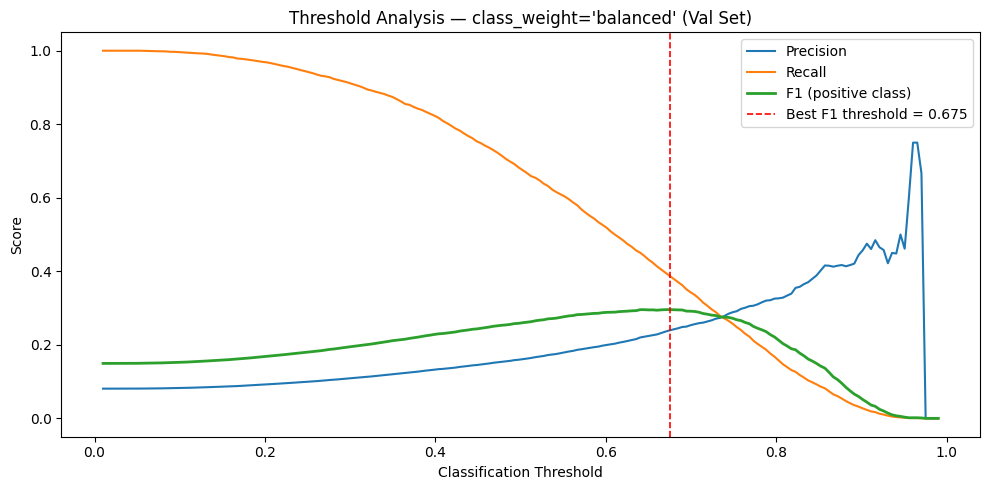


--- Test set evaluation at optimal threshold ---

  Test (threshold=0.675) — threshold = 0.6748241206030151
  ROC-AUC : 0.7521
  PR-AUC  : 0.2350

                precision    recall  f1-score   support

No Default (0)       0.94      0.89      0.92     42402
   Default (1)       0.24      0.40      0.30      3724

      accuracy                           0.85     46126
     macro avg       0.59      0.64      0.61     46126
  weighted avg       0.89      0.85      0.87     46126



In [9]:
# Pick the model with the higher val ROC-AUC as the "best" baseline
best_model = lr_base if results_base_val["roc_auc"] >= results_smote_val["roc_auc"] else lr_smote
best_label = "class_weight='balanced'" if best_model is lr_base else "SMOTE"
print(f"Best baseline model: {best_label}")

y_prob_val = best_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)
metrics = []
for t in thresholds:
    y_pred_t = (y_prob_val >= t).astype(int)
    tp = ((y_pred_t == 1) & (y_val == 1)).sum()
    fp = ((y_pred_t == 1) & (y_val == 0)).sum()
    fn = ((y_pred_t == 0) & (y_val == 1)).sum()
    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec   = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1    = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    metrics.append({"threshold": t, "precision": prec, "recall": rec, "f1": f1})

metrics_df = pd.DataFrame(metrics)
best_t_row = metrics_df.loc[metrics_df["f1"].idxmax()]
best_threshold = best_t_row["threshold"]

print(f"\nBest F1 threshold on val set : {best_threshold:.3f}")
print(f"  Precision : {best_t_row['precision']:.4f}")
print(f"  Recall    : {best_t_row['recall']:.4f}")
print(f"  F1        : {best_t_row['f1']:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(metrics_df["threshold"], metrics_df["precision"], label="Precision", linewidth=1.5)
ax.plot(metrics_df["threshold"], metrics_df["recall"],    label="Recall",    linewidth=1.5)
ax.plot(metrics_df["threshold"], metrics_df["f1"],        label="F1 (positive class)", linewidth=2)
ax.axvline(best_threshold, color='red', linestyle='--', linewidth=1.2,
           label=f"Best F1 threshold = {best_threshold:.3f}")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title(f"Threshold Analysis — {best_label} (Val Set)")
ax.legend()
plt.tight_layout()
plt.show()

# Evaluate best model at the optimal threshold on test set
print("\n--- Test set evaluation at optimal threshold ---")
_ = evaluate_model(best_model, X_test, y_test,
                   split_name=f"Test (threshold={best_threshold:.3f})",
                   threshold=best_threshold)

## 8. Feature Importance — Top Coefficients

Logistic Regression coefficients directly reflect feature influence on the log-odds of default.
We plot the **top 20 positive** (increase default risk) and **top 20 negative** (decrease default risk) features.

> All features were standardised in preprocessing so coefficient magnitudes are comparable.

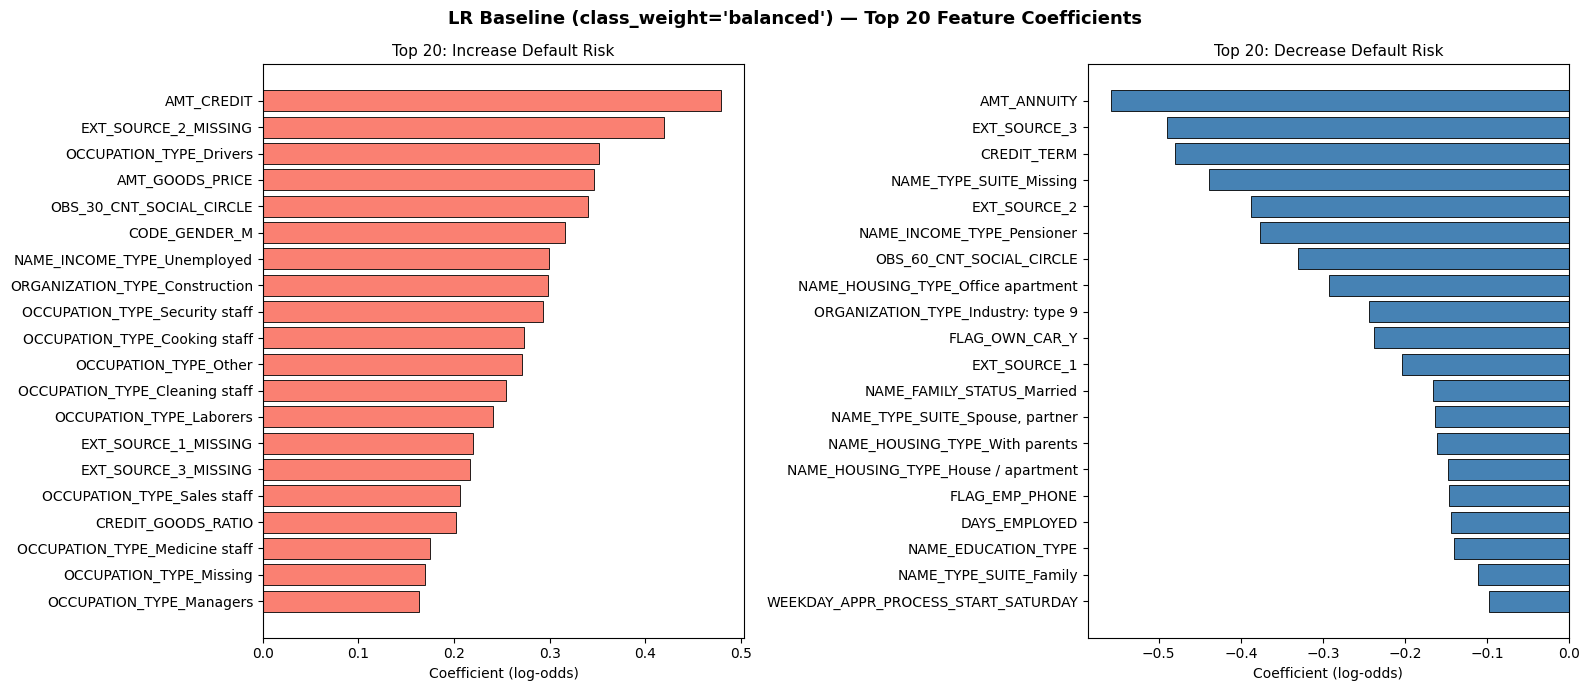


Full coefficient table (sorted by magnitude):


,feature,coefficient
2,AMT_ANNUITY,-0.558600
6,EXT_SOURCE_3,-0.489466
107,CREDIT_TERM,-0.479614
1,AMT_CREDIT,0.479596
14,NAME_TYPE_SUITE_Missing,-0.438973
110,EXT_SOURCE_2_MISSING,0.419905
5,EXT_SOURCE_2,-0.387632
21,NAME_INCOME_TYPE_Pensioner,-0.376259
59,OCCUPATION_TYPE_Drivers,0.351208
3,AMT_GOODS_PRICE,0.346900


In [10]:
coef_df = pd.DataFrame({
    "feature"    : feature_names,
    "coefficient": best_model.coef_[0],
}).sort_values("coefficient", ascending=False)

top_pos = coef_df.head(20)
top_neg = coef_df.tail(20).sort_values("coefficient")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f"LR Baseline ({best_label}) — Top 20 Feature Coefficients",
             fontsize=13, fontweight='bold')

# Positive coefficients — increase default risk
axes[0].barh(top_pos["feature"], top_pos["coefficient"],
             color="salmon", edgecolor="black", linewidth=0.6)
axes[0].set_title("Top 20: Increase Default Risk", fontsize=11)
axes[0].set_xlabel("Coefficient (log-odds)")
axes[0].invert_yaxis()

# Negative coefficients — decrease default risk
axes[1].barh(top_neg["feature"], top_neg["coefficient"],
             color="steelblue", edgecolor="black", linewidth=0.6)
axes[1].set_title("Top 20: Decrease Default Risk", fontsize=11)
axes[1].set_xlabel("Coefficient (log-odds)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nFull coefficient table (sorted by magnitude):")
coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df.sort_values("abs_coef", ascending=False).drop(columns="abs_coef").head(30)

## 9. Save Results

Save the best model's test-set predictions and the summary table for later comparison with
Random Forest, MLP, and Elastic Net in the final results notebook.

In [11]:
import joblib, os

OUT_DIR = "/content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models"
os.makedirs(OUT_DIR, exist_ok=True)

# Save best model
joblib.dump(best_model, f"{OUT_DIR}/lr_baseline.pkl")
print(f"Saved model  -> {OUT_DIR}/lr_baseline.pkl")

# Save test predictions + probabilities
y_prob_test = best_model.predict_proba(X_test)[:, 1]
preds_df = pd.DataFrame({
    "y_true"    : y_test.values,
    "y_prob"    : y_prob_test,
    "y_pred_05" : (y_prob_test >= 0.5).astype(int),
    "y_pred_opt": (y_prob_test >= best_threshold).astype(int),
})
preds_df.to_csv(f"{OUT_DIR}/lr_baseline_test_preds.csv", index=False)
print(f"Saved preds  -> {OUT_DIR}/lr_baseline_test_preds.csv")

# Save summary
summary.to_csv(f"{OUT_DIR}/lr_baseline_summary.csv", index=False)
print(f"Saved summary-> {OUT_DIR}/lr_baseline_summary.csv")

# Save feature importances
coef_out = coef_df[["feature", "coefficient"]].copy()
coef_out["abs_coef"] = coef_out["coefficient"].abs()
coef_out = coef_out.sort_values("abs_coef", ascending=False).drop(columns="abs_coef")
coef_out.to_csv(f"{OUT_DIR}/lr_baseline_coefficients.csv", index=False)
print(f"Saved coefs  -> {OUT_DIR}/lr_baseline_coefficients.csv")

print("\nAll outputs saved successfully.")

Saved model  -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/lr_baseline.pkl
Saved preds  -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/lr_baseline_test_preds.csv
Saved summary-> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/lr_baseline_summary.csv
Saved coefs  -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/lr_baseline_coefficients.csv

All outputs saved successfully.


## 10. Summary & Takeaways

| Model | Training Set | Val ROC-AUC | Test ROC-AUC | Val PR-AUC | Test PR-AUC |
|---|---|---|---|---|---|
| LR Baseline | Original (class_weight=balanced) | *see results above* | ... | ... | ... |
| LR Baseline | SMOTE | *see results above* | ... | ... | ... |

**What to expect from this baseline:**
- Logistic Regression with balanced weights typically reaches **ROC-AUC ≈ 0.73–0.75** on the Home Credit dataset.
- This establishes the floor: any model in the project must beat this AUC to justify its complexity.
- EXT_SOURCE_1/2/3 dominate the coefficient magnitudes — consistent with EDA findings.

**Next steps:**
- `04_random_forest.ipynb` — tree ensemble, no scaling needed, can capture nonlinear interactions
- `05_mlp.ipynb` — neural network baseline, same scaled features
- `06_elastic_net.ipynb` — regularised LR, automatic feature selection via L1+L2